Libraries Imported Successfully ✅
Dataset Loaded Successfully ✅
Dataset Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


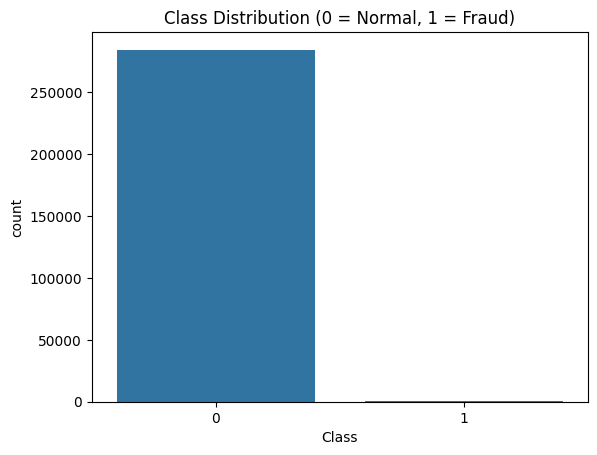

Data Preprocessed Successfully ✅
Model Trained Successfully ✅

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9605494455801453


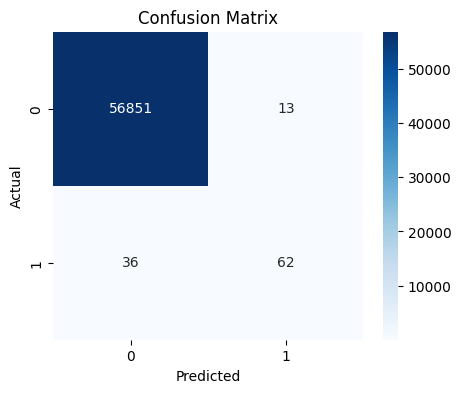

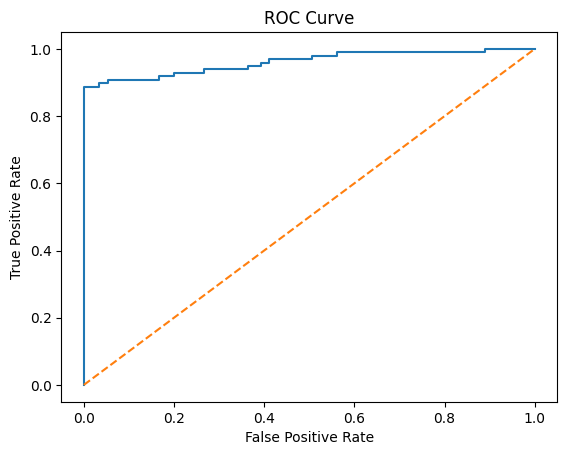

Project Execution Completed Successfully 🚀


In [1]:
# ============================================
# 💳 Credit Card Fraud Detection
# Machine Learning Classification Project
# ============================================

# -------- 1️⃣ Import Libraries --------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("Libraries Imported Successfully ✅")


# -------- 2️⃣ Download Dataset Automatically --------
# Public hosted CSV version of Kaggle dataset

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data = pd.read_csv(url)

print("Dataset Loaded Successfully ✅")
print("Dataset Shape:", data.shape)


# -------- 3️⃣ Basic Exploration --------
print("\nClass Distribution:")
print(data['Class'].value_counts())

# Plot class imbalance
sns.countplot(x='Class', data=data)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()


# -------- 4️⃣ Data Preprocessing --------
X = data.drop("Class", axis=1)
y = data["Class"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Preprocessed Successfully ✅")


# -------- 5️⃣ Train Logistic Regression Model --------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Trained Successfully ✅")


# -------- 6️⃣ Predictions --------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# -------- 7️⃣ Evaluation --------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


# -------- 8️⃣ Confusion Matrix --------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -------- 9️⃣ ROC Curve --------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


print("Project Execution Completed Successfully 🚀")